In [1]:
# Cell 1
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, eigsh

# Create the directory for saving figures
os.makedirs("figureAKLT", exist_ok=True)

def truncate_svd(X, D_max, tol=1e-10):
    """
    Algorithm 2: TruncateBySVD
    Truncates a matrix X using SVD up to a maximum bond dimension D_max 
    and singular value tolerance tol.
    """
    U, S, Vh = np.linalg.svd(X, full_matrices=False)
    
    # Retain bond dimension D based on tolerance and D_max
    D = min(D_max, np.sum(S > tol))
    D = max(D, 1) # Keep at least 1 singular value
    
    U_trunc = U[:, :D]
    S_trunc = S[:D]
    Vh_trunc = Vh[:D, :]
    
    discarded_weight = np.sum(S[D:]**2)
    
    return U_trunc, S_trunc, Vh_trunc, discarded_weight

def left_canonicalize_qr(M):
    """
    Left canonicalize a single tensor M by reduced QR without pivoting.
    M shape: (D_{i-1}, d_i, D_i)
    Returns: 
        A: Left-canonical tensor of shape (D_{i-1}, d_i, D_new)
        R: Upper triangular matrix of shape (D_new, D_i) to be absorbed to the right
    """
    D_left, d, D_right = M.shape
    
    # Eq (1): Left-grouped matrix reshape
    M_mat = M.reshape((D_left * d, D_right), order='C')
    
    # Reduced QR
    Q, R = np.linalg.qr(M_mat, mode='reduced')
    D_new = Q.shape[1]
    
    # Reshape Q into left-canonical MPS tensor
    A = Q.reshape((D_left, d, D_new), order='C')
    
    return A, R

def right_canonicalize_qr(M):
    """
    Right canonicalize a single tensor M by reduced QR without pivoting.
    M shape: (D_{i-1}, d_i, D_i)
    Returns: 
        L_mat: Matrix of shape (D_{i-1}, D_new) to be absorbed to the left
        B: Right-canonical tensor of shape (D_new, d_i, D_i)
    """
    D_left, d, D_right = M.shape
    
    # Eq (2): Right-grouped matrix reshape
    M_mat = M.reshape((D_left, d * D_right), order='C')
    
    # Reduced QR on Hermitian transpose
    Q, R = np.linalg.qr(M_mat.T.conj(), mode='reduced')
    D_new = Q.shape[1]
    
    # M_mat = (Q R)^dagger = R^dagger Q^dagger
    L_mat = R.T.conj()
    B_mat = Q.T.conj()
    
    # Reshape into right-canonical MPS tensor
    B = B_mat.reshape((D_new, d, D_right), order='C')
    
    return L_mat, B

def init_random_mps(L, d, D_max):
    """
    Initialize a random complex MPS with open boundary conditions.
    """
    MPS = []
    D_left = 1
    for i in range(L):
        # Bound D_right by max allowed by Hilbert space and D_max
        D_right = min(D_max, d**(i+1), d**(L-1-i))
        if i == L - 1:
            D_right = 1
            
        M = np.random.randn(D_left, d, D_right) + 1j * np.random.randn(D_left, d, D_right)
        M /= np.linalg.norm(M) # Normalize local tensor
        MPS.append(M.astype(np.complex128))
        
        D_left = D_right
        
    return MPS

In [2]:
# Cell 2

# =====================================================================
# Section 6: Heisenberg S=1/2 MPO
# =====================================================================

def get_heisenberg_mpo(L, J=1.0, Jz=1.0, h=0.0):
    """
    Constructs the MPO for the spin-1/2 Heisenberg XXZ chain with open boundary conditions.
    chi = 5.
    """
    d = 2
    I_2 = np.eye(2, dtype=np.complex128)
    Sp_2 = np.array([[0, 1], [0, 0]], dtype=np.complex128)
    Sm_2 = np.array([[0, 0], [1, 0]], dtype=np.complex128)
    Sz_2 = 0.5 * np.array([[1, 0], [0, -1]], dtype=np.complex128)
    
    W_bulk = np.zeros((5, 5, d, d), dtype=np.complex128)
    
    # Fill bulk MPO entries (lower triangular convention)
    W_bulk[0, 0] = I_2
    W_bulk[1, 0] = Sp_2
    W_bulk[2, 0] = Sm_2
    W_bulk[3, 0] = Sz_2
    
    W_bulk[4, 0] = -h * Sz_2
    W_bulk[4, 1] = (J / 2.0) * Sm_2
    W_bulk[4, 2] = (J / 2.0) * Sp_2
    W_bulk[4, 3] = Jz * Sz_2
    W_bulk[4, 4] = I_2
    
    MPO = []
    for i in range(L):
        if i == 0:
            # Left boundary selects the bottom row of W_bulk
            W_left = np.zeros((1, 5, d, d), dtype=np.complex128)
            W_left[0, :] = W_bulk[4, :]
            MPO.append(W_left)
        elif i == L - 1:
            # Right boundary selects the leftmost column of W_bulk
            W_right = np.zeros((5, 1, d, d), dtype=np.complex128)
            W_right[:, 0] = W_bulk[:, 0]
            MPO.append(W_right)
        else:
            MPO.append(W_bulk.copy())
            
    return MPO

# =====================================================================
# Section 7: AKLT S=1 Hamiltonian MPO
# =====================================================================

def get_aklt_mpo(L):
    """
    Constructs the exact MPO for the spin-1 AKLT Hamiltonian with open boundary conditions.
    chi = 14.
    """
    d = 3
    I_3 = np.eye(3, dtype=np.complex128)
    Sz_3 = np.array([[1, 0, 0], 
                     [0, 0, 0], 
                     [0, 0, -1]], dtype=np.complex128)
    Sp_3 = np.sqrt(2) * np.array([[0, 1, 0], 
                                  [0, 0, 1], 
                                  [0, 0, 0]], dtype=np.complex128)
    Sm_3 = np.sqrt(2) * np.array([[0, 0, 0], 
                                  [1, 0, 0], 
                                  [0, 1, 0]], dtype=np.complex128)
    
    # Define O_a and Obar_a
    O1 = (1.0 / np.sqrt(2)) * Sp_3
    O2 = (1.0 / np.sqrt(2)) * Sm_3
    O3 = Sz_3
    O = [O1, O2, O3]
    
    Obar1 = (1.0 / np.sqrt(2)) * Sm_3
    Obar2 = (1.0 / np.sqrt(2)) * Sp_3
    Obar3 = Sz_3
    Obar = [Obar1, Obar2, Obar3]
    
    # Define O_a O_b and Obar_a Obar_b in lexicographical order
    O2_list = []
    Obar2_list = []
    for a in range(3):
        for b in range(3):
            O2_list.append(O[a] @ O[b])
            Obar2_list.append(Obar[a] @ Obar[b])
            
    # Assemble the Bulk Operator-Valued MPO
    W_bulk = np.zeros((14, 14, d, d), dtype=np.complex128)
    
    # 0 -> 0: Identity
    W_bulk[0, 0] = I_3
    
    # 0 -> a (a=1..3): O_a
    for a in range(3):
        W_bulk[0, 1 + a] = O[a]
        
    # 0 -> (a,b) (indices 4..12): (1/3) O_a O_b
    for ab in range(9):
        W_bulk[0, 4 + ab] = (1.0 / 3.0) * O2_list[ab]
        
    # a -> 13: Obar_a
    for a in range(3):
        W_bulk[1 + a, 13] = Obar[a]
        
    # (a,b) -> 13: Obar_a Obar_b
    for ab in range(9):
        W_bulk[4 + ab, 13] = Obar2_list[ab]
        
    # 13 -> 13: Identity
    W_bulk[13, 13] = I_3
    
    MPO = []
    for i in range(L):
        if i == 0:
            # Left boundary: top row of the block MPO
            W_left = np.zeros((1, 14, d, d), dtype=np.complex128)
            W_left[0, :] = W_bulk[0, :]
            MPO.append(W_left)
        elif i == L - 1:
            # Right boundary: rightmost column of the block MPO
            W_right = np.zeros((14, 1, d, d), dtype=np.complex128)
            W_right[:, 0] = W_bulk[:, 13]
            MPO.append(W_right)
        else:
            MPO.append(W_bulk.copy())
            
    return MPO

In [3]:
# Cell 3 (Updated Eigensolver Limits)

# =====================================================================
# Section 8: MPO Environments
# =====================================================================

def init_env(chi, D):
    env = np.zeros((chi, D, D), dtype=np.complex128)
    env[0, 0, 0] = 1.0
    return env

def update_left_env(Lold, A, W):
    # Validated NumPy implementation
    Lnew = np.einsum('bxy,xsa,bBst,ytc->Bac', Lold, A, W, A.conj())
    return Lnew

def update_right_env(Rold, B, W):
    # Validated NumPy implementation
    Rnew = np.einsum('xsa,bBst,Bac,ytc->bxy', B, W, Rold, B.conj())
    return Rnew

# =====================================================================
# Sections 9 & 11: One-site Effective Hamiltonian
# =====================================================================

def heff_one_site_matvec(v, L, W, R, Dl, d, Dr):
    M = v.reshape((Dl, d, Dr), order='C')
    X  = np.einsum('byx,ysz->bxsz', L, M)
    Y  = np.einsum('bBst,bxsz->Bxtz', W, X)
    HM = np.einsum('Bxtz,Bza->xta', Y, R)
    return HM.reshape(Dl * d * Dr, order='C')

def solve_one_site(L, W, R, M_guess):
    Dl, d, Dr = M_guess.shape
    Nloc = Dl * d * Dr
    
    Heff = LinearOperator(
        shape=(Nloc, Nloc),
        matvec=lambda v: heff_one_site_matvec(v, L, W, R, Dl, d, Dr),
        dtype=np.complex128
    )
    
    v0 = M_guess.reshape(Nloc, order='C')
    # ADDED: tol=1e-5 and maxiter=100 to prevent degenerate stalling
    evals, evecs = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-5, maxiter=100)
    
    E0 = evals[0]
    M_new = evecs[:, 0].reshape((Dl, d, Dr), order='C')
    return E0, M_new

# =====================================================================
# Sections 10 & 11: Two-site Effective Hamiltonian
# =====================================================================

def heff_two_site_matvec(v, L, W1, W2, R, Dl, d1, d2, Dr):
    Theta = v.reshape((Dl, d1, d2, Dr), order='C')
    X  = np.einsum('byx,yuvz->bxuvz', L, Theta)
    Y  = np.einsum('bBus,bxuvz->Bxsvz', W1, X)
    Z  = np.einsum('BCvt,Bxsvz->Cxstz', W2, Y)
    HT = np.einsum('Cxstz,Cza->xsta', Z, R)
    return HT.reshape(Dl * d1 * d2 * Dr, order='C')

def solve_two_site(L, W1, W2, R, Theta_guess):
    Dl, d1, d2, Dr = Theta_guess.shape
    Nloc = Dl * d1 * d2 * Dr
    
    Heff = LinearOperator(
        shape=(Nloc, Nloc),
        matvec=lambda v: heff_two_site_matvec(v, L, W1, W2, R, Dl, d1, d2, Dr),
        dtype=np.complex128
    )
    
    v0 = Theta_guess.reshape(Nloc, order='C')
    # ADDED: tol=1e-5 and maxiter=100 to prevent degenerate stalling
    evals, evecs = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-5, maxiter=100)
    
    E0 = evals[0]
    Theta_new = evecs[:, 0].reshape((Dl, d1, d2, Dr), order='C')
    return E0, Theta_new

In [4]:
# Cell 4 (Corrected)

# =====================================================================
# Section 12: Two-Site DMRG
# =====================================================================

def two_site_dmrg(MPS_initial, MPO, D_max, tol=1e-8, max_sweeps=10, svd_tol=1e-12):
    """
    Algorithm 2: TwoSiteDMRG
    Optimizes the MPS to find the ground state of the given MPO.
    """
    L = len(MPS_initial)
    MPS = [M.copy() for M in MPS_initial]
    W = MPO
    
    # 1. Bring initial MPS into mixed-canonical form (center at site 0)
    # Right-canonicalize from right to left
    for i in range(L - 1, 0, -1):
        L_mat, B = right_canonicalize_qr(MPS[i])
        MPS[i] = B
        # Absorb L_mat into the tensor to the left
        MPS[i-1] = np.einsum('xsa,ab->xsb', MPS[i-1], L_mat)
        
    MPS[0] /= np.linalg.norm(MPS[0]) # Normalize the overall state
        
    # 2. Build initial environments
    L_envs = [None] * L
    R_envs = [None] * L
    
    # Boundary conditions for open chains
    L_envs[0] = init_env(1, 1)   # chi_0=1, D_0=1
    R_envs[L-1] = init_env(1, 1) # chi_L=1, D_L=1
    
    # Pre-build right environments (since center is at site 0)
    for i in range(L - 1, 0, -1):
        R_envs[i-1] = update_right_env(R_envs[i], MPS[i], W[i])
        
    energies = []
    max_trunc_errs = []
    
    for sweep in range(max_sweeps):
        E_sweep = 0.0
        max_err = 0.0
        
        # -------------------------------------------------------------
        # Left-to-Right sweep
        # -------------------------------------------------------------
        for i in range(L - 1):
            # Form current two-site center tensor (Eq 49)
            # Center M is at i, right-canonical B is at i+1
            # CORRECTED: xsa, atb -> xstb (trace out bond index a)
            Theta = np.einsum('xsa,atb->xstb', MPS[i], MPS[i+1])
            Dl, d1, d2, Dr = Theta.shape
            
            # Solve lowest-eigenvalue problem
            E, Theta_opt = solve_two_site(L_envs[i], W[i], W[i+1], R_envs[i+1], Theta)
            E_sweep = E
            
            # Reshape for SVD (Eq 50)
            Theta_mat = Theta_opt.reshape((Dl * d1, d2 * Dr), order='C')
            
            # SVD and truncate
            U_trunc, S_trunc, Vh_trunc, err = truncate_svd(Theta_mat, D_max, tol=svd_tol)
            max_err = max(max_err, err)
            D_new = len(S_trunc)
            
            # Update tensors (Eqs 53, 54)
            A = U_trunc.reshape((Dl, d1, D_new), order='C')
            M_next = (np.diag(S_trunc) @ Vh_trunc).reshape((D_new, d2, Dr), order='C')
            
            MPS[i] = A
            MPS[i+1] = M_next
            
            # Update left environment for the next bond
            L_envs[i+1] = update_left_env(L_envs[i], MPS[i], W[i])
            
        # -------------------------------------------------------------
        # Right-to-Left sweep
        # -------------------------------------------------------------
        for i in range(L - 2, -1, -1):
            # Form current two-site center tensor
            # Left-canonical A is at i, center M is at i+1
            # CORRECTED: xsa, atb -> xstb
            Theta = np.einsum('xsa,atb->xstb', MPS[i], MPS[i+1])
            Dl, d1, d2, Dr = Theta.shape
            
            # Solve lowest-eigenvalue problem
            E, Theta_opt = solve_two_site(L_envs[i], W[i], W[i+1], R_envs[i+1], Theta)
            E_sweep = E
            
            # Reshape for SVD (Eq 50)
            Theta_mat = Theta_opt.reshape((Dl * d1, d2 * Dr), order='C')
            
            # SVD and truncate
            U_trunc, S_trunc, Vh_trunc, err = truncate_svd(Theta_mat, D_max, tol=svd_tol)
            max_err = max(max_err, err)
            D_new = len(S_trunc)
            
            # Update tensors (Eqs 55, 56)
            M_prev = (U_trunc @ np.diag(S_trunc)).reshape((Dl, d1, D_new), order='C')
            B = Vh_trunc.reshape((D_new, d2, Dr), order='C')
            
            MPS[i] = M_prev
            MPS[i+1] = B
            
            # Update right environment for the next bond
            R_envs[i] = update_right_env(R_envs[i+1], MPS[i+1], W[i+1])
            
        energies.append(E_sweep)
        max_trunc_errs.append(max_err)
        
        print(f"Sweep {sweep+1}/{max_sweeps} | Energy: {E_sweep.real:.10f} | Max Discarded Weight: {max_err:.4e}")
        
        # Convergence diagnostic
        if sweep > 0 and abs(energies[-1] - energies[-2]) < tol:
            print("Energy converged.")
            break
            
    return energies[-1].real, MPS, energies, max_trunc_errs

 Running Two-Site DMRG for S=1/2 Heisenberg Model
 L = 20, D_max = 20
Sweep 1/12 | Energy: -8.6824729142 | Max Discarded Weight: 1.7832e-08
Sweep 2/12 | Energy: -8.6824729137 | Max Discarded Weight: 1.9204e-08
Energy converged.

 Running Two-Site DMRG for S=1 AKLT Model
 L = 20, D_max = 20
Sweep 1/12 | Energy: -12.6666666667 | Max Discarded Weight: 9.3873e-09
Sweep 2/12 | Energy: -12.6666666667 | Max Discarded Weight: 9.7203e-22
Energy converged.

=== AKLT Benchmark ===
Exact Analytical Energy : -12.6666666667
DMRG Converged Energy   : -12.6666666667
Absolute Error          : 7.1054e-15

Figures successfully saved to: figureAKLT\dmrg_convergence.png


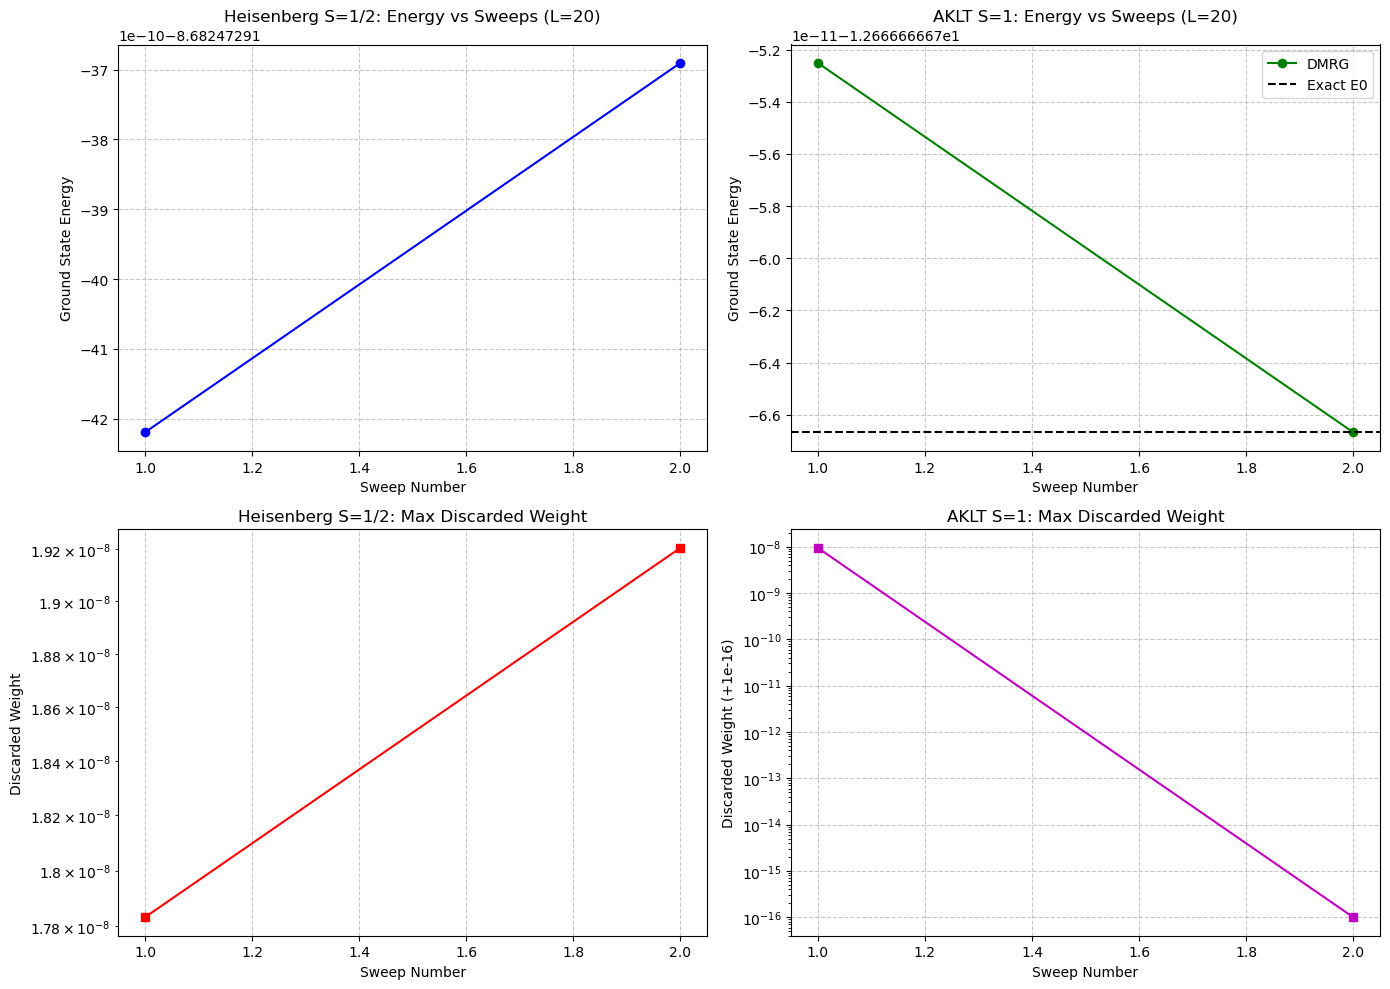

In [5]:
# Cell 5 (Updated execution with D_max=20)

# =====================================================================
# DMRG Execution and Validation
# =====================================================================

L = 20           # System size 
D_max = 20       # Maximum bond dimension (20 is plenty for testing these L=20 models)
max_sweeps = 12  # Number of sweeps
tol = 1e-8       # Overall energy convergence tolerance

print("==================================================")
print(f" Running Two-Site DMRG for S=1/2 Heisenberg Model")
print(f" L = {L}, D_max = {D_max}")
print("==================================================")

mpo_heis = get_heisenberg_mpo(L, J=1.0, Jz=1.0, h=0.0)
mps_init_heis = init_random_mps(L, d=2, D_max=D_max)

E_heis, mps_heis, energies_heis, errs_heis = two_site_dmrg(
    mps_init_heis, mpo_heis, D_max=D_max, tol=tol, max_sweeps=max_sweeps
)

print("\n==================================================")
print(f" Running Two-Site DMRG for S=1 AKLT Model")
print(f" L = {L}, D_max = {D_max}")
print("==================================================")

mpo_aklt = get_aklt_mpo(L)
mps_init_aklt = init_random_mps(L, d=3, D_max=D_max)

E_aklt, mps_aklt, energies_aklt, errs_aklt = two_site_dmrg(
    mps_init_aklt, mpo_aklt, D_max=D_max, tol=tol, max_sweeps=max_sweeps
)

# Exact AKLT Ground State Energy Check
E_exact_aklt = -(2.0 / 3.0) * (L - 1)
print("\n=== AKLT Benchmark ===")
print(f"Exact Analytical Energy : {E_exact_aklt:.10f}")
print(f"DMRG Converged Energy   : {E_aklt:.10f}")
print(f"Absolute Error          : {abs(E_aklt - E_exact_aklt):.4e}")

# =====================================================================
# Plotting and Saving the Results
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heisenberg Energy Convergence
axes[0, 0].plot(range(1, len(energies_heis) + 1), energies_heis, marker='o', color='b')
axes[0, 0].set_title(f"Heisenberg S=1/2: Energy vs Sweeps (L={L})", fontsize=12)
axes[0, 0].set_xlabel("Sweep Number", fontsize=10)
axes[0, 0].set_ylabel("Ground State Energy", fontsize=10)
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# Heisenberg Discarded Weight
axes[1, 0].semilogy(range(1, len(errs_heis) + 1), errs_heis, marker='s', color='r')
axes[1, 0].set_title("Heisenberg S=1/2: Max Discarded Weight", fontsize=12)
axes[1, 0].set_xlabel("Sweep Number", fontsize=10)
axes[1, 0].set_ylabel("Discarded Weight", fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# AKLT Energy Convergence
axes[0, 1].plot(range(1, len(energies_aklt) + 1), energies_aklt, marker='o', color='g', label='DMRG')
axes[0, 1].axhline(E_exact_aklt, color='k', linestyle='--', label='Exact E0')
axes[0, 1].set_title(f"AKLT S=1: Energy vs Sweeps (L={L})", fontsize=12)
axes[0, 1].set_xlabel("Sweep Number", fontsize=10)
axes[0, 1].set_ylabel("Ground State Energy", fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# AKLT Discarded Weight
# Using +1e-16 to avoid log(0) issues since AKLT truncation error should essentially hit machine zero
axes[1, 1].semilogy(range(1, len(errs_aklt) + 1), np.array(errs_aklt) + 1e-16, marker='s', color='m')
axes[1, 1].set_title("AKLT S=1: Max Discarded Weight", fontsize=12)
axes[1, 1].set_xlabel("Sweep Number", fontsize=10)
axes[1, 1].set_ylabel("Discarded Weight (+1e-16)", fontsize=10)
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# Save the figure to the specified directory
save_path = os.path.join("figureAKLT", "dmrg_convergence.png")
plt.savefig(save_path, dpi=300)
print(f"\nFigures successfully saved to: {save_path}")

plt.show()

In [6]:
# Cell 6

# =====================================================================
# Section 13: One-Site DMRG
# =====================================================================

def one_site_dmrg(MPS_initial, MPO, D_max, tol=1e-8, max_sweeps=5, svd_tol=1e-12):
    """
    Algorithm 3: OneSiteDMRG
    Optimizes the MPS using one-site local updates.
    It is highly recommended to pass an MPS that has already been pre-optimized 
    by two-site DMRG to avoid local minima.
    """
    L = len(MPS_initial)
    MPS = [M.copy() for M in MPS_initial]
    W = MPO
    
    # 1. Bring initial MPS into mixed-canonical form (center at site 0)
    for i in range(L - 1, 0, -1):
        L_mat, B = right_canonicalize_qr(MPS[i])
        MPS[i] = B
        MPS[i-1] = np.einsum('xsa,ab->xsb', MPS[i-1], L_mat)
        
    MPS[0] /= np.linalg.norm(MPS[0]) # Normalize
        
    # 2. Build initial environments
    L_envs = [None] * L
    R_envs = [None] * L
    
    L_envs[0] = init_env(1, 1)
    R_envs[L-1] = init_env(1, 1)
    
    # Pre-build right environments
    for i in range(L - 1, 0, -1):
        R_envs[i-1] = update_right_env(R_envs[i], MPS[i], W[i])
        
    energies = []
    max_trunc_errs = []
    
    for sweep in range(max_sweeps):
        E_sweep = 0.0
        max_err = 0.0
        
        # -------------------------------------------------------------
        # Left-to-Right sweep
        # -------------------------------------------------------------
        for i in range(L - 1):
            # Solve one-site effective-Hamiltonian problem
            E, M_opt = solve_one_site(L_envs[i], W[i], R_envs[i], MPS[i])
            E_sweep = E
            
            Dl, d, Dr = M_opt.shape
            
            # Reshape center tensor as a left-grouped matrix (Eq 1)
            M_mat = M_opt.reshape((Dl * d, Dr), order='C')
            
            # Compute SVD and truncate
            U_trunc, S_trunc, Vh_trunc, err = truncate_svd(M_mat, D_max, tol=svd_tol)
            max_err = max(max_err, err)
            D_new = len(S_trunc)
            
            # Reshape U -> A (left-canonical)
            A = U_trunc.reshape((Dl, d, D_new), order='C')
            MPS[i] = A
            
            # Absorb S V^\dagger into M^{[i+1]}
            SVh = np.diag(S_trunc) @ Vh_trunc
            MPS[i+1] = np.einsum('ab,bsc->asc', SVh, MPS[i+1])
            
            # Update left environment
            L_envs[i+1] = update_left_env(L_envs[i], MPS[i], W[i])
            
        # -------------------------------------------------------------
        # Right-to-Left sweep
        # -------------------------------------------------------------
        # Center is now at site L-1. Sweep from L-1 down to 1.
        for i in range(L - 1, 0, -1):
            # Solve one-site effective-Hamiltonian problem
            E, M_opt = solve_one_site(L_envs[i], W[i], R_envs[i], MPS[i])
            E_sweep = E
            
            Dl, d, Dr = M_opt.shape
            
            # Reshape center tensor as a right-grouped matrix (Eq 2)
            M_mat = M_opt.reshape((Dl, d * Dr), order='C')
            
            # Compute SVD and truncate
            U_trunc, S_trunc, Vh_trunc, err = truncate_svd(M_mat, D_max, tol=svd_tol)
            max_err = max(max_err, err)
            D_new = len(S_trunc)
            
            # Reshape V^\dagger -> B (right-canonical)
            B = Vh_trunc.reshape((D_new, d, Dr), order='C')
            MPS[i] = B
            
            # Absorb U S into M^{[i-1]}
            US = U_trunc @ np.diag(S_trunc)
            MPS[i-1] = np.einsum('xsa,ab->xsb', MPS[i-1], US)
            
            # Update right environment
            R_envs[i-1] = update_right_env(R_envs[i], MPS[i], W[i])
            
        energies.append(E_sweep)
        max_trunc_errs.append(max_err)
        
        print(f"1-Site Sweep {sweep+1}/{max_sweeps} | Energy: {E_sweep.real:.10f} | Max Discarded Weight: {max_err:.4e}")
        
        if sweep > 0 and abs(energies[-1] - energies[-2]) < tol:
            print("1-Site Energy converged.")
            break
            
    return energies[-1].real, MPS, energies, max_trunc_errs

In [7]:
# Cell 7

# =====================================================================
# Testing One-Site DMRG Refinement
# =====================================================================

print("==================================================")
print(f" Refining Heisenberg Model with One-Site DMRG")
print(f" Using converged Two-Site MPS as initial guess")
print("==================================================")

# We use the converged MPS `mps_heis` from our Two-Site run in Cell 5.
# This prevents the One-Site algorithm from getting stuck in local minima.
E_1site_heis, mps_1site_heis, energies_1site, errs_1site = one_site_dmrg(
    mps_heis, mpo_heis, D_max=20, tol=1e-9, max_sweeps=5
)

E_diff = E_1site_heis - E_heis

print("\n=== One-Site vs Two-Site Benchmark ===")
print(f"Final Two-Site Energy : {E_heis:.10f}")
print(f"Final One-Site Energy : {E_1site_heis:.10f}")
print(f"Energy Difference     : {E_diff:.4e}")
if E_diff < 0:
    print("-> One-site DMRG successfully lowered the energy further (fine-tuning)!")
else:
    print("-> Energy remained stable, confirming the two-site state was fully converged.")

 Refining Heisenberg Model with One-Site DMRG
 Using converged Two-Site MPS as initial guess
1-Site Sweep 1/5 | Energy: -8.6824729191 | Max Discarded Weight: 0.0000e+00
1-Site Sweep 2/5 | Energy: -8.6824729191 | Max Discarded Weight: 0.0000e+00
1-Site Energy converged.

=== One-Site vs Two-Site Benchmark ===
Final Two-Site Energy : -8.6824729137
Final One-Site Energy : -8.6824729191
Energy Difference     : -5.4047e-09
-> One-site DMRG successfully lowered the energy further (fine-tuning)!


 Diagnostics for Final S=1/2 Heisenberg State
Energy Variance <H^2> - <H>^2 : 1.3742e-06

 Diagnostics for Final S=1 AKLT State
Energy Variance <H^2> - <H>^2 : 1.7053e-13

Magnetization figure saved to: figureAKLT\magnetization.png


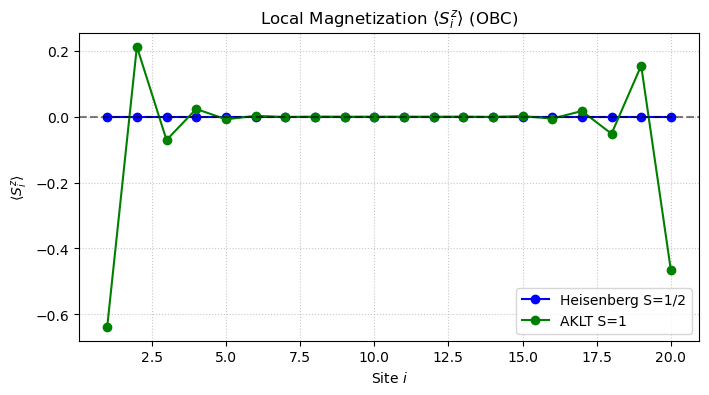

In [9]:
# Cell 8 (Corrected)

# =====================================================================
# Section 15: Convergence Diagnostics & Observables
# =====================================================================

def apply_mpo_to_mps(MPO, MPS):
    """
    Applies an MPO to an MPS to create a new MPS.
    |phi> = H |psi>
    The new bond dimension is D_new = chi * D.
    """
    L = len(MPS)
    new_MPS = []
    
    for i in range(L):
        W = MPO[i] # Shape: (chi_{i-1}, chi_i, d, d) -> [b, B, s, t]
        M = MPS[i] # Shape: (D_{i-1}, d, D_i)        -> [x, t, y]
        
        # Contract the physical bra index 't' of W with physical index 't' of M.
        # Order the output as: left(b, x), physical(s), right(B, y)
        T = np.einsum('bBst,xty->bxsBy', W, M)
        
        chi_l, D_l, d, chi_r, D_r = T.shape
        
        # Group the left and right bond indices
        new_M = T.reshape((chi_l * D_l, d, chi_r * D_r), order='C')
        new_MPS.append(new_M)
        
    return new_MPS

def mps_overlap(MPS1, MPS2):
    """
    Computes the overlap <MPS1 | MPS2>.
    """
    L = len(MPS1)
    # Initialize left boundary
    E = np.ones((1, 1), dtype=np.complex128)
    
    for i in range(L):
        M1 = MPS1[i] # bra: (D1_{i-1}, d, D1_i)
        M2 = MPS2[i] # ket: (D2_{i-1}, d, D2_i)
        
        # Contract E(ab) with M2(bcd) -> T(acd)
        T = np.einsum('ab,bcd->acd', E, M2)
        # Contract T(acd) with M1*(ace) -> E_new(ed)
        E = np.einsum('acd,ace->ed', T, M1.conj())
        
    return E[0, 0]

def compute_variance(MPO, MPS, E_current):
    """
    Computes the energy variance sigma^2 = <H^2> - <H>^2.
    """
    # 1. Compute |phi> = H |psi>
    H_psi = apply_mpo_to_mps(MPO, MPS)
    
    # 2. <H^2> = <phi | phi>
    H2_exp = mps_overlap(H_psi, H_psi).real
    
    # 3. Variance = <H^2> - <H>^2
    variance = H2_exp - (E_current ** 2)
    return variance

def measure_local_Sz(MPS, d=2):
    """
    Measures the local <Sz_i> across the chain.
    Requires the MPS to be brought into right-canonical form first, 
    and then left-canonicalized site-by-site during measurement.
    """
    L = len(MPS)
    MPS_copy = [M.copy() for M in MPS]
    
    if d == 2:
        Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=np.complex128)
    elif d == 3:
        Sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=np.complex128)
        
    # Bring entirely to right-canonical form (center at 0)
    for i in range(L - 1, 0, -1):
        L_mat, B = right_canonicalize_qr(MPS_copy[i])
        MPS_copy[i] = B
        MPS_copy[i-1] = np.einsum('xsa,ab->xsb', MPS_copy[i-1], L_mat)
        
    # Normalize
    MPS_copy[0] /= np.linalg.norm(MPS_copy[0])
    
    sz_vals = []
    # Sweep left-to-right to measure
    for i in range(L):
        # M is the center tensor
        M = MPS_copy[i]
        
        # Measure <Sz> at site i
        # Tr(M^\dagger * Sz * M)
        val = np.einsum('xsa,st,xta->', M.conj(), Sz, M).real
        sz_vals.append(val)
        
        # Shift center to i+1
        if i < L - 1:
            A, R = left_canonicalize_qr(M)
            MPS_copy[i] = A
            MPS_copy[i+1] = np.einsum('ab,bsc->asc', R, MPS_copy[i+1])
            
    return sz_vals

# =====================================================================
# Execution: Measuring Properties
# =====================================================================

print("==================================================")
print(" Diagnostics for Final S=1/2 Heisenberg State")
print("==================================================")

var_heis = compute_variance(mpo_heis, mps_1site_heis, E_1site_heis)
print(f"Energy Variance <H^2> - <H>^2 : {var_heis:.4e}")

sz_heis = measure_local_Sz(mps_1site_heis, d=2)

print("\n==================================================")
print(" Diagnostics for Final S=1 AKLT State")
print("==================================================")

var_aklt = compute_variance(mpo_aklt, mps_aklt, E_aklt)
print(f"Energy Variance <H^2> - <H>^2 : {var_aklt:.4e}")

sz_aklt = measure_local_Sz(mps_aklt, d=3)

# Plotting the local magnetization
plt.figure(figsize=(8, 4))
plt.plot(range(1, L+1), sz_heis, 'bo-', label='Heisenberg S=1/2')
plt.plot(range(1, L+1), sz_aklt, 'go-', label='AKLT S=1')
plt.title(r"Local Magnetization $\langle S^z_i \rangle$ (OBC)", fontsize=12)
plt.xlabel("Site $i$", fontsize=10)
plt.ylabel(r"$\langle S^z_i \rangle$", fontsize=10)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

save_path_sz = os.path.join("figureAKLT", "magnetization.png")
plt.savefig(save_path_sz, dpi=300)
print(f"\nMagnetization figure saved to: {save_path_sz}")
plt.show()

 Half-Chain Entanglement Entropy (Cut at bond 9)
Heisenberg S=1/2 : 0.634558
AKLT S=1         : 0.693147

Figures successfully saved to: figureAKLT\correlations_and_entanglement.png


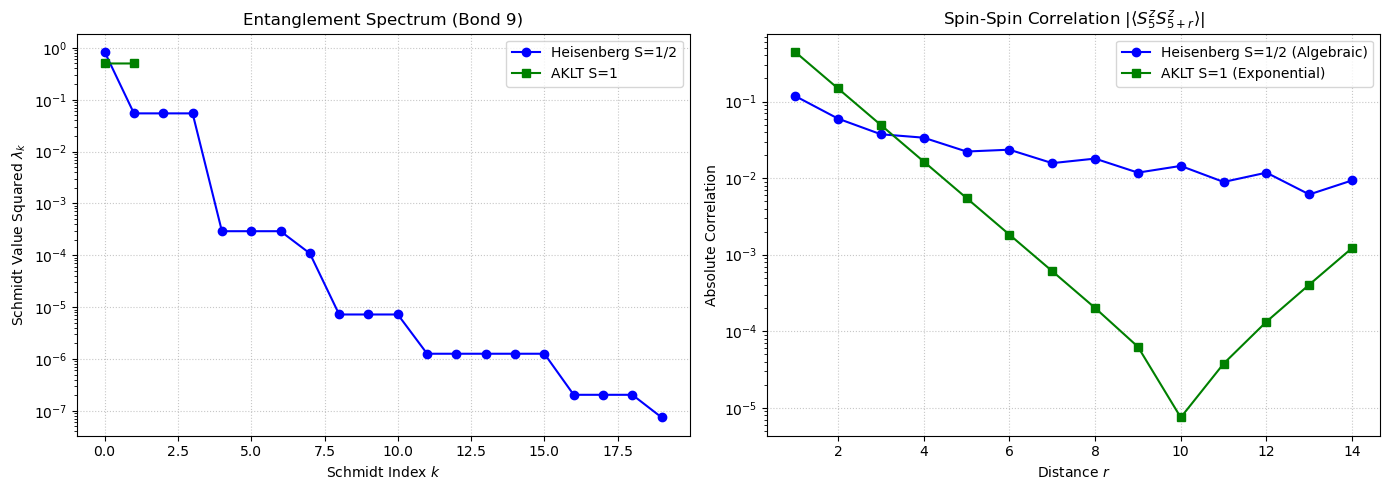

In [10]:
# Cell 9

# =====================================================================
# Entanglement Entropy and Correlation Functions
# =====================================================================

def compute_entanglement(MPS, bond_index):
    """
    Computes the Schmidt values and Von Neumann entanglement entropy 
    at the bond to the right of 'bond_index'.
    """
    L = len(MPS)
    MPS_copy = [M.copy() for M in MPS]
    
    # 1. Right-canonicalize all the way to site 0
    for i in range(L - 1, 0, -1):
        L_mat, B = right_canonicalize_qr(MPS_copy[i])
        MPS_copy[i] = B
        MPS_copy[i-1] = np.einsum('xsa,ab->xsb', MPS_copy[i-1], L_mat)
    MPS_copy[0] /= np.linalg.norm(MPS_copy[0])
    
    # 2. Left-canonicalize up to 'bond_index'
    for i in range(bond_index):
        A, R = left_canonicalize_qr(MPS_copy[i])
        MPS_copy[i] = A
        MPS_copy[i+1] = np.einsum('ab,bsc->asc', R, MPS_copy[i+1])
        
    # 3. The center is now at bond_index. Reshape and SVD to get Schmidt values on its right bond.
    M = MPS_copy[bond_index]
    Dl, d, Dr = M.shape
    M_mat = M.reshape((Dl * d, Dr), order='C')
    U, S, Vh = np.linalg.svd(M_mat, full_matrices=False)
    
    # Filter strictly positive singular values
    S = S[S > 1e-14]
    
    # Entanglement Entropy S = - \sum \lambda_k \log(\lambda_k), where \lambda_k = S_k^2
    lambdas = S**2
    EE = -np.sum(lambdas * np.log(lambdas))
    
    return S, EE

def measure_correlation_SzSz(MPS, site_i, d=2):
    """
    Measures the two-point correlation function C(j) = <Sz_i Sz_j> for all j > site_i.
    """
    L = len(MPS)
    MPS_copy = [M.copy() for M in MPS]
    
    if d == 2:
        Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=np.complex128)
    elif d == 3:
        Sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=np.complex128)
        
    # 1. Bring to right-canonical (center at 0)
    for i in range(L - 1, 0, -1):
        L_mat, B = right_canonicalize_qr(MPS_copy[i])
        MPS_copy[i] = B
        MPS_copy[i-1] = np.einsum('xsa,ab->xsb', MPS_copy[i-1], L_mat)
    MPS_copy[0] /= np.linalg.norm(MPS_copy[0])
    
    # 2. Shift center up to site_i
    for i in range(site_i):
        A, R = left_canonicalize_qr(MPS_copy[i])
        MPS_copy[i] = A
        MPS_copy[i+1] = np.einsum('ab,bsc->asc', R, MPS_copy[i+1])
        
    correlations = []
    
    # 3. Initialize Transfer matrix T at site_i containing Sz
    M_i = MPS_copy[site_i]
    
    # Contract M_i(ket) with Sz and M_i*(bra)
    # ket: 'a' is right open bond, bra: 'b' is right open bond
    T = np.einsum('xta,st,xsb->ab', M_i, Sz, M_i.conj())
    
    # 4. Push T through the lattice for j > site_i
    for j in range(site_i + 1, L):
        M_j = MPS_copy[j]
        
        # Measure at j: close the trace with Sz
        val = np.einsum('ab,atc,st,bsc->', T, M_j, Sz, M_j.conj()).real
        correlations.append(val)
        
        # Update T for the next site (Identity operator, no Sz)
        # T_new[c, C] = T[a, b] * M[a, s, c] * M*[b, s, C]
        T = np.einsum('ab,asc,bsC->cC', T, M_j, M_j.conj())
        
    return correlations

# =====================================================================
# Execution: Measurements
# =====================================================================

# Compute half-chain Entanglement Entropy (bond L//2 - 1)
center_bond = L // 2 - 1

S_heis, EE_heis = compute_entanglement(mps_1site_heis, center_bond)
S_aklt, EE_aklt = compute_entanglement(mps_aklt, center_bond)

print("==================================================")
print(f" Half-Chain Entanglement Entropy (Cut at bond {center_bond})")
print("==================================================")
print(f"Heisenberg S=1/2 : {EE_heis:.6f}")
print(f"AKLT S=1         : {EE_aklt:.6f}")

# Compute Correlations <Sz_i Sz_j> starting from site_i = L//4 to avoid left edge effects
site_i = L // 4

corr_heis = measure_correlation_SzSz(mps_1site_heis, site_i, d=2)
corr_aklt = measure_correlation_SzSz(mps_aklt, site_i, d=3)

distances = np.arange(1, len(corr_heis) + 1)

# Absolute value of correlations (to plot on log scale)
abs_corr_heis = np.abs(corr_heis)
abs_corr_aklt = np.abs(corr_aklt)

# =====================================================================
# Plotting
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Entanglement Spectrum
axes[0].plot(S_heis**2, 'bo-', label='Heisenberg S=1/2')
axes[0].plot(S_aklt**2, 'gs-', label='AKLT S=1')
axes[0].set_yscale('log')
axes[0].set_title(f"Entanglement Spectrum (Bond {center_bond})", fontsize=12)
axes[0].set_xlabel("Schmidt Index $k$", fontsize=10)
axes[0].set_ylabel(r"Schmidt Value Squared $\lambda_k$", fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# 2. Spin-Spin Correlations
axes[1].plot(distances, abs_corr_heis, 'bo-', label='Heisenberg S=1/2 (Algebraic)')
axes[1].plot(distances, abs_corr_aklt, 'gs-', label='AKLT S=1 (Exponential)')
axes[1].set_yscale('log')
axes[1].set_title(f"Spin-Spin Correlation $|\\langle S^z_{{{site_i}}} S^z_{{{site_i}+r}} \\rangle|$", fontsize=12)
axes[1].set_xlabel("Distance $r$", fontsize=10)
axes[1].set_ylabel(r"Absolute Correlation", fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()

save_path_corr = os.path.join("figureAKLT", "correlations_and_entanglement.png")
plt.savefig(save_path_corr, dpi=300)
print(f"\nFigures successfully saved to: {save_path_corr}")
plt.show()